In [1]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score
import pickle
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [2]:
df = pd.read_csv(r"C:\Users\chand\Downloads\IMDB-Dataset.csv")

In [3]:
df


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
df.sentiment.replace("positive",1,inplace = True)
df.sentiment.replace("negative",0,inplace = True)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [7]:
df.review[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

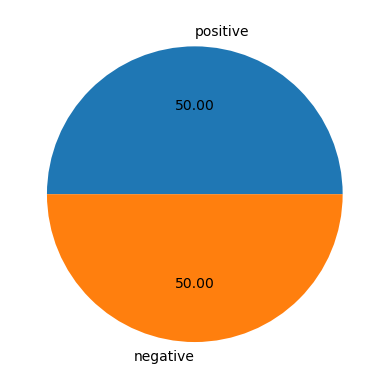

In [8]:
import matplotlib.pyplot as plt
plt.pie(df['sentiment'].value_counts(), labels=['positive','negative'],autopct="%0.2f")
plt.show()



In [9]:
df['num_characters'] = df['review'].apply(len)
df['num_characters']

0        1761
1         998
2         926
3         748
4        1317
         ... 
49995    1008
49996     642
49997    1280
49998    1234
49999     678
Name: num_characters, Length: 50000, dtype: int64

In [10]:
import nltk
df['num_words'] = df['review'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,review,sentiment,num_characters,num_words
0,One of the other reviewers has mentioned that ...,1,1761,380
1,A wonderful little production. <br /><br />The...,1,998,201
2,I thought this was a wonderful way to spend ti...,1,926,205
3,Basically there's a family where a little boy ...,0,748,175
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,283


In [11]:
df['num_sentences'] = df['review'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [12]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,50000.000000,50000.000000,50000.000000
mean,1309.431020,279.483480,10.741440
std,989.728014,207.949644,7.900587
min,32.000000,8.000000,1.000000
25%,699.000000,151.000000,6.000000
50%,970.000000,209.000000,9.000000
75%,1590.250000,340.000000,13.000000
max,13704.000000,2911.000000,282.000000


In [13]:
df[df['sentiment'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,25000.000000,25000.000000,25000.000000
mean,1294.064360,278.609120,11.026880
std,945.892669,201.294517,7.880229
min,32.000000,8.000000,1.000000
25%,706.000000,153.000000,6.000000
50%,973.000000,211.000000,9.000000
75%,1567.250000,338.000000,13.000000
max,8969.000000,1936.000000,118.000000


In [14]:
df[df['review'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


C:\Users\chand\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\chand\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\chand\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


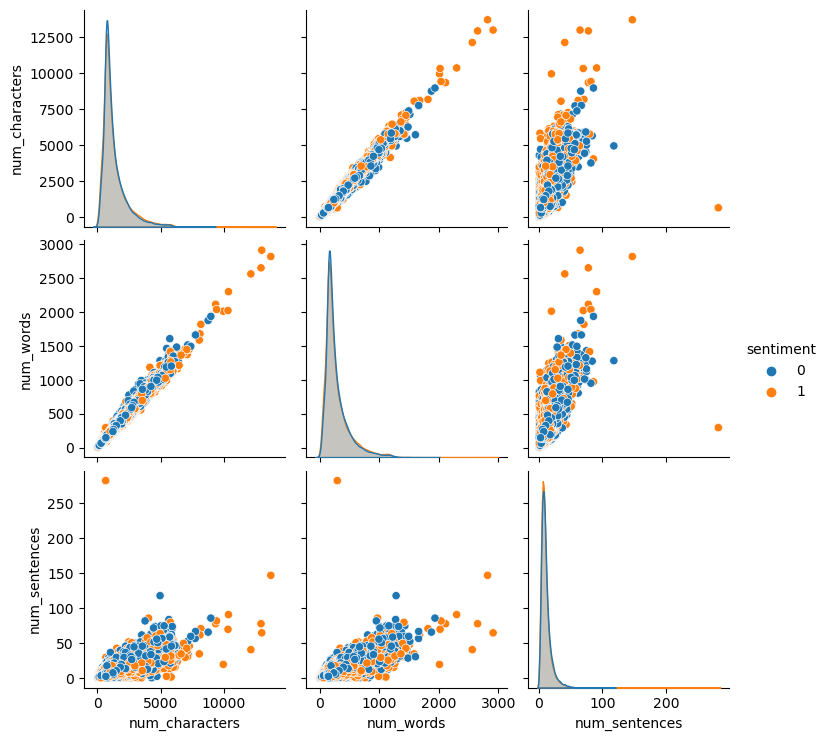

In [15]:
import seaborn as sns
sns.pairplot(df,hue='sentiment')

In [16]:
df

,review,sentiment,num_characters,num_words,num_sentences
0,One of the other reviewers has mentioned that ...,1,1761,380,10
1,A wonderful little production. <br /><br />The...,1,998,201,7
2,I thought this was a wonderful way to spend ti...,1,926,205,4
3,Basically there's a family where a little boy ...,0,748,175,6
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,283,9
...,...,...,...,...,...
49995,I thought this movie did a down right good job...,1,1008,241,8
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0,642,138,3
49997,I am a Catholic taught in parochial elementary...,0,1280,271,6
49998,I'm going to have to disagree with the previou...,0,1234,240,8


<Axes: >

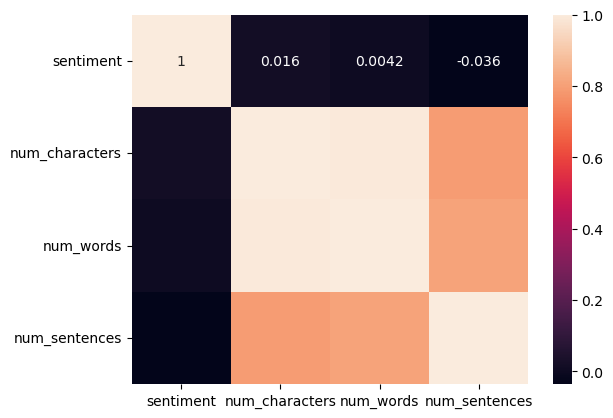

In [17]:
# Exclude non-numeric columns from correlation analysis
numeric_df = df.select_dtypes(include=['number'])

# Plot correlation heatmap
sns.heatmap(numeric_df.corr(), annot=True)


In [18]:
# Text Vectorization
# using Bag of Words
df.head()

,review,sentiment,num_characters,num_words,num_sentences
0,One of the other reviewers has mentioned that ...,1,1761,380,10
1,A wonderful little production. <br /><br />The...,1,998,201,7
2,I thought this was a wonderful way to spend ti...,1,926,205,4
3,Basically there's a family where a little boy ...,0,748,175,6
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,283,9


In [19]:


def remove_html_tags(sentence):
    clean_sentence = re.sub(r'<.*?>', '', sentence)
    return clean_sentence
df.review = df.review.apply(remove_html_tags)
df.review[1]


'A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well done.'

In [20]:
def remove_special_characters(sentence):
    # Define a pattern to match special characters
    pattern = r'[^a-zA-Z0-9\s]'  # This pattern will match any character that is not a letter, digit, or whitespace
    
    # Use re.sub() to replace special characters with an empty string
    clean_sentence = re.sub(pattern, '', sentence)
    
    return clean_sentence
df.review = df.review.apply(remove_special_characters)
df.review[1]


'A wonderful little production The filming technique is very unassuming very oldtimeBBC fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece The actors are extremely well chosen Michael Sheen not only has got all the polari but he has all the voices down pat too You can truly see the seamless editing guided by the references to Williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece A masterful production about one of the great masters of comedy and his life The realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears It plays on our knowledge and our senses particularly with the scenes concerning Orton and Halliwell and the sets particularly of their flat with Halliwells murals decorating every surface are terribly well done'

In [21]:
def to_lower(text):
    return text.lower()

df.review = df.review.apply(to_lower)
df.review[0]

'one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictur

In [22]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chand\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [23]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [24]:
def rem_stopwords(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text)
    return [w for w in words if w not in stop_words]

dfreview = df.review.apply(rem_stopwords)
df.review[0]

'one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictur

In [25]:
from nltk.stem import PorterStemmer
def preprocess_text(text):
    
    # Initialize Porter Stemmer
    stemmer = PorterStemmer()
    
    # Tokenize the text
    words = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_words = [w for w in words if w.lower() not in stop_words]
    
    # Stem the words
    stemmed_words = [stemmer.stem(word) for word in filtered_words]
    
    # Join the stemmed words back into a single string
    preprocessed_text = ' '.join(stemmed_words)
    
    return preprocessed_text


df.review = df.review.apply(preprocess_text)

In [26]:
!pip install wordcloud
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [27]:
df['transformed_text'] = df['review'].apply(preprocess_text)

In [28]:
positive_wc = wc.generate(df[df['sentiment'] == 1]['transformed_text'].str.cat(sep=" "))

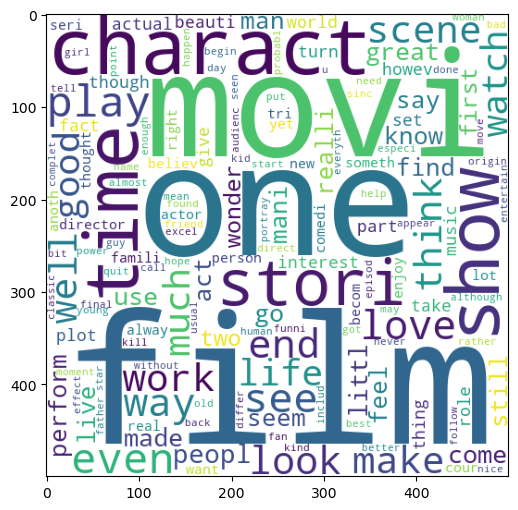

In [29]:
plt.figure(figsize=(15,6))
plt.imshow(positive_wc)

In [30]:
negative_wc = wc.generate(df[df['sentiment'] == 0]['transformed_text'].str.cat(sep=" "))

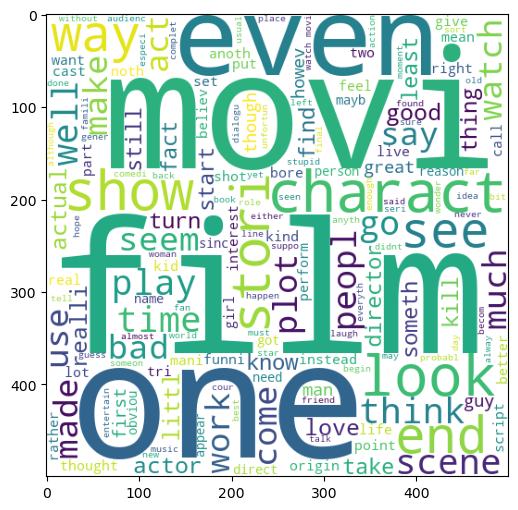

In [31]:
plt.figure(figsize=(15,6))
plt.imshow(negative_wc)

In [32]:
positive_corpus = []
for msg in df[df['sentiment'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        positive_corpus.append(word)

In [33]:
len(positive_corpus)

3011109

In [34]:
negative_corpus = []
for msg in df[df['sentiment'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        negative_corpus.append(word)

In [35]:
len(negative_corpus)

2942571

In [36]:
X = np.array(df.iloc[:,0].values)
y = np.array(df.sentiment.values)
cv = CountVectorizer(max_features = 1000)
X = cv.fit_transform(df.review).toarray()
print("X.shape = ",X.shape)
print("y.shape = ",y.shape)

X.shape =  (50000, 1000)
y.shape =  (50000,)


In [37]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# X = np.array(df.iloc[:,0].values)
# y = np.array(df.sentiment.values)
# # Initialize TfidfVectorizer
# tfidf_vectorizer = TfidfVectorizer()

# # Fit and transform the corpus to create TF-IDF representation
# X = tfidf_vectorizer.fit_transform(df.review)

# # Get the vocabulary
# tfidf_vocab = tfidf_vectorizer.get_feature_names_out()

# print("X.shape = ",X.shape)
# print("y.shape = ",y.shape)

In [38]:
train_x,test_x,train_y,test_y = train_test_split(X,y,test_size=0.2,random_state=9)
print("Train shapes : X = {}, y = {}".format(train_x.shape,train_y.shape))
print("Test shapes : X = {}, y = {}".format(test_x.shape,test_y.shape))

Train shapes : X = (40000, 1000), y = (40000,)
Test shapes : X = (10000, 1000), y = (10000,)


In [39]:
gnb,mnb,bnb = GaussianNB(),MultinomialNB(alpha=1.0,fit_prior=True),BernoulliNB(alpha=1.0,fit_prior=True)
gnb.fit(train_x,train_y)
mnb.fit(train_x,train_y)
bnb.fit(train_x,train_y)


BernoulliNB()

In [40]:
ypg = gnb.predict(test_x)
ypm = mnb.predict(test_x)
ypb = bnb.predict(test_x)

print("Gaussian = ",accuracy_score(test_y,ypg))
print("Multinomial = ",accuracy_score(test_y,ypm))
print("Bernoulli = ",accuracy_score(test_y,ypb))

Gaussian =  0.7827
Multinomial =  0.8248
Bernoulli =  0.8283


In [41]:
print(accuracy_score(test_y,ypg))
print(confusion_matrix(test_y,ypm))
print(precision_score(test_y,ypb))

0.7827
[[4145  878]
 [ 874 4103]]
0.8167508744656043


In [42]:
!pip install xgboost

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
!pip install xgboost

In [44]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [45]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [46]:
def train_classifier(clf,train_x,train_y,test_x,test_y):
    clf.fit(train_x,train_y)
    y_pred = clf.predict(test_x)
    accuracy = accuracy_score(test_y,y_pred)
    precision = precision_score(test_y,y_pred)
    
    return accuracy,precision

In [ ]:
train_classifier(svc,train_x,train_y,test_x,test_y)

In [48]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, train_x,train_y,test_x,test_y)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.5458
Precision -  0.5433008162452717
For  KN
Accuracy -  0.6636
Precision -  0.6380284100633237
For  NB
Accuracy -  0.8248
Precision -  0.8237301746637221
For  DT
Accuracy -  0.7038
Precision -  0.648139979414792
For  LR
Accuracy -  0.8601
Precision -  0.8538370253164557
For  RF
Accuracy -  0.8239
Precision -  0.8300492610837439
For  AdaBoost
Accuracy -  0.8074
Precision -  0.7902949571836346
For  BgC
Accuracy -  0.7899
Precision -  0.7870259481037924
For  ETC
Accuracy -  0.8296
Precision -  0.8411507191994997
For  GBDT
Accuracy -  0.7817
Precision -  0.7449158485273493
For  xgb
Accuracy -  0.8363
Precision -  0.8196784073506891


In [49]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [50]:
performance_df

,Algorithm,Accuracy,Precision
4,LR,0.8601,0.853837
8,ETC,0.8296,0.841151
5,RF,0.8239,0.830049
2,NB,0.8248,0.823730
10,xgb,0.8363,0.819678
6,AdaBoost,0.8074,0.790295
7,BgC,0.7899,0.787026
9,GBDT,0.7817,0.744916
3,DT,0.7038,0.648140
1,KN,0.6636,0.638028


In [51]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [52]:
performance_df1

,Algorithm,variable,value
0,LR,Accuracy,0.860100
1,ETC,Accuracy,0.829600
2,RF,Accuracy,0.823900
3,NB,Accuracy,0.824800
4,xgb,Accuracy,0.836300
5,AdaBoost,Accuracy,0.807400
6,BgC,Accuracy,0.789900
7,GBDT,Accuracy,0.781700
8,DT,Accuracy,0.703800
9,KN,Accuracy,0.663600


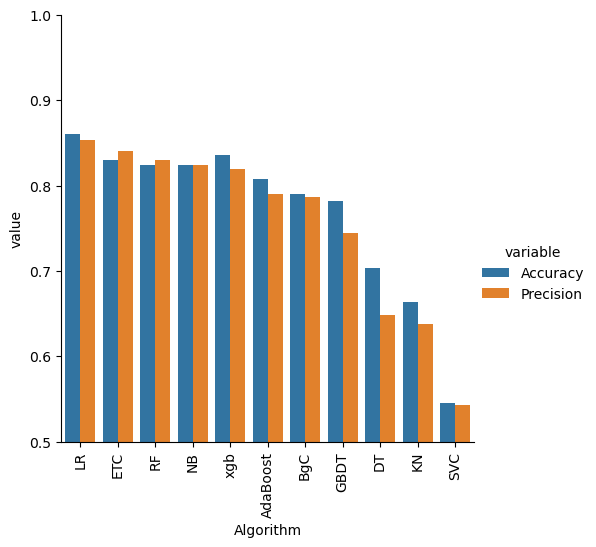

In [53]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()




In [54]:
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [55]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [56]:
voting.fit(train_x,train_y)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [57]:
y_pred = voting.predict(test_x)
print("Accuracy",accuracy_score(test_y,y_pred))
print("Precision",precision_score(test_y,y_pred))

Accuracy 0.8323
Precision 0.8285543608124253


In [58]:
import pickle
pickle.dump(voting,open('model1.pkl','wb'))

In [59]:
pickle.dump(cv, open('vectorizer.pkl', 'wb'))

In [60]:
import sklearn
print(sklearn.__version__)


1.2.2


In [61]:
The plot was engaging, and the characters were well-developed. I was on the edge of my seat throughout the entire movie

SyntaxError: invalid syntax (987562947.py, line 1)